# Install & Setup

In [1]:
!pip install -U transformers datasets scikit-learn

import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


# Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

In [3]:
df = pd.read_excel('toxic_labeled.xlsx')

# Clean
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(float)

# Split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 7196
Val: 1800


# Tokenization

In [4]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

def preprocess(examples):
    tokens = tokenizer(
        examples['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    tokens["labels"] = [[float(l)] for l in examples["label"]]

    return tokens

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
val_dataset = val_dataset.map(preprocess, batched=True, remove_columns=val_dataset.column_names)

train_dataset.set_format(type='torch')
val_dataset.set_format(type='torch')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7196 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

# Model + Training

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="multi_label_classification"  # better for sigmoid
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits.squeeze()))
    return {"roc_auc": roc_auc_score(labels, probs)}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.204120,0.216137,0.987672
2,0.086024,0.206722,0.990949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1800, training_loss=0.27389340851042004, metrics={'train_runtime': 602.3435, 'train_samples_per_second': 23.893, 'train_steps_per_second': 2.988, 'total_flos': 946665077385216.0, 'train_loss': 0.27389340851042004, 'epoch': 2.0})

# Save Model

In [6]:
model.save_pretrained("model")
tokenizer.save_pretrained("model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('model/tokenizer_config.json', 'model/tokenizer.json')

# Test Inference

In [7]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model(**inputs)
    logits = outputs.logits.detach().cpu().numpy()

    prob = float(1 / (1 + np.exp(-logits[0][0])))
    label = 1 if prob >= 0.5 else 0

    return prob, label

# Test
text = "You are stupid"
print(predict(text))

(0.9987648725509644, 1)


# Upload Evaluation Dataset

In [8]:
uploaded = files.upload()
eval_df = pd.read_excel('toxic_no_label_evaluation.xlsx')

# Generate Submission

In [12]:
predictions = []

for text in eval_df['text']:
    _, label = predict(str(text))
    predictions.append(label)

submission_df = pd.DataFrame({
    "text" : eval_df['text'],
    "label": predictions
})

submission_df.to_csv("submission.csv", index=False)

print("Submission saved!")
submission_df.head()

Submission saved!


,text,label
0,सपना तो कोई भी देख सकता है चाहे कोई भी जाति या...,1
1,Anushka Sharma is one of the best. She is the ...,0
2,भारतीय शास्त्रीय संगीत के विश्वविख्यात नाम पंड...,0
3,Bet he biggest pussy ever wit no gun in hand.,1
4,बच्चे पैदा करते हैं कहते हैं अल्लाह की देन है ...,1


### Model Evaluation
After training, we evaluate the model's performance on the validation dataset using the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) score. This metric is particularly useful for measuring the model's ability to distinguish between toxic and non-toxic classes.

Final Validation ROC-AUC: 0.9909


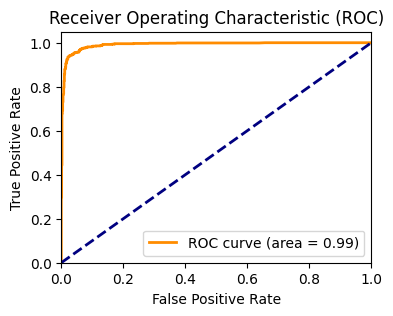

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions from the trainer
val_predictions = trainer.predict(val_dataset)
logits = val_predictions.predictions.squeeze()
labels = val_predictions.label_ids.squeeze()

# Convert logits to probabilities
probs = 1 / (1 + np.exp(-logits))

# Calculate final ROC-AUC
final_auc = roc_auc_score(labels, probs)
print(f"Final Validation ROC-AUC: {final_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()